In [1]:
import glob

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import numpy as np

from unseen import fileio
import spatial

In [2]:
mask = spatial.get_mask()

In [3]:
def get_model_data(metric, model):
    """Get grid point data for a single metric/model combination"""

    var = {'txx': 'tasmax', 'rx1day': 'pr'}
    path = f'/g/data/xv83/unseen-projects/outputs/bias/data/independence-{metric}_{model}-*_*_annual-jul-to-jun_AUS300i.nc'
    model_file = glob.glob(path)[0]
    ds = fileio.open_dataset(model_file)

    return ds['min_lead'].where(mask)

In [8]:
models = [
    'BCC-CSM2-MR',
    'CAFE (May)',
    'CAFE (Nov)',
    'CMCC-CM2-SR5',
    'CanESM5',
    'EC-Earth3',
    'IPSL-CM6A-LR',
    'MIROC6',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'NorCPM1',
]

In [9]:
txx_dict = {}
for model in models:
    if model == 'CAFE (May)':
        da = get_model_data('txx', 'CAFE')
        da_may = da.sel({'month': 5})
        txx_dict['CAFE (May)'] = da_may
        da_mean_may = float(da_may.mean())
        print(f'CAFE (May) mean: {da_mean_may:.1f}')
    elif model == 'CAFE (Nov)':
        da = get_model_data('txx', 'CAFE')
        da_nov = da.sel({'month': 11})
        txx_dict['CAFE (Nov)'] = da_nov
        da_mean_nov = float(da_nov.mean())
        print(f'CAFE (Nov) mean: {da_mean_nov:.1f}')
    else:
        da = get_model_data('txx', model)
        txx_dict[model] = da
        da_mean = float(da.mean())
        print(f'{model} mean: {da_mean:.1f}')

BCC-CSM2-MR mean: 0.2
CAFE (May) mean: 2.2
CAFE (Nov) mean: 2.4
CMCC-CM2-SR5 mean: 3.8
CanESM5 mean: 2.2
EC-Earth3 mean: 1.3
IPSL-CM6A-LR mean: 1.3
MIROC6 mean: 2.9
MPI-ESM1-2-HR mean: 0.0
MRI-ESM2-0 mean: 0.4
NorCPM1 mean: 1.2


In [10]:
rx1day_dict = {}
for model in models:
    if model == 'CAFE (May)':
        da = get_model_data('rx1day', 'CAFE')
        da_may = da.sel({'month': 5})
        rx1day_dict['CAFE (May)'] = da_may
        da_mean_may = float(da_may.mean())
        print(f'CAFE (May) mean: {da_mean_may:.1f}')
    elif model == 'CAFE (Nov)':
        da = get_model_data('rx1day', 'CAFE')
        da_nov = da.sel({'month': 11})
        rx1day_dict['CAFE (Nov)'] = da_nov
        da_mean_nov = float(da_nov.mean())
        print(f'CAFE (Nov) mean: {da_mean_nov:.1f}')
    else:
        da = get_model_data('rx1day', model)
        rx1day_dict[model] = da
        da_mean = float(da.mean())
        print(f'{model} mean: {da_mean:.1f}')

BCC-CSM2-MR mean: 0.1
CAFE (May) mean: 1.6
CAFE (Nov) mean: 1.2
CMCC-CM2-SR5 mean: 0.2
CanESM5 mean: 0.2
EC-Earth3 mean: 0.0
IPSL-CM6A-LR mean: 0.0
MIROC6 mean: 0.1
MPI-ESM1-2-HR mean: 0.0
MRI-ESM2-0 mean: 0.1
NorCPM1 mean: 0.3


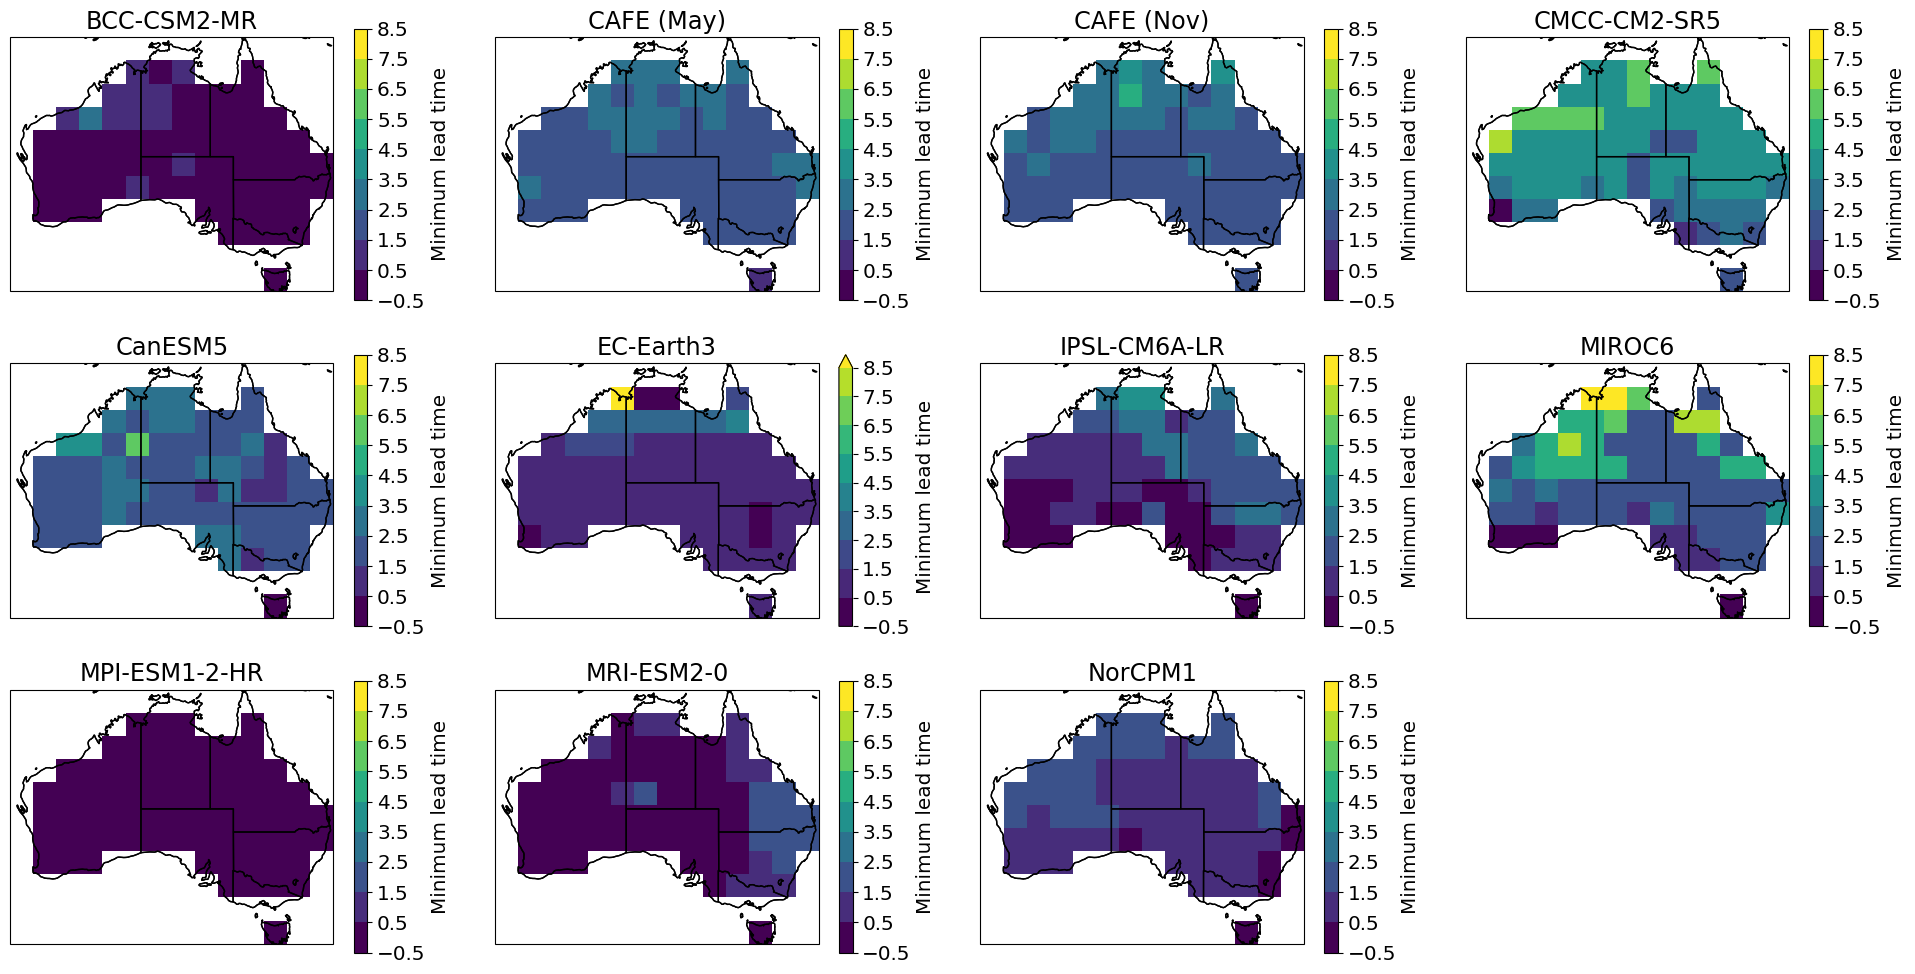

In [19]:
levels = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5] 

fig = plt.figure(figsize=[24, 12])

for plot_num, model in enumerate(models):
    ax = fig.add_subplot(3, 4, plot_num+1, projection=ccrs.PlateCarree())
    im = txx_dict[model].plot(ax=ax, transform=ccrs.PlateCarree(), levels=levels, cmap='viridis')
    ax.set_title(model)
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)

plt.show()

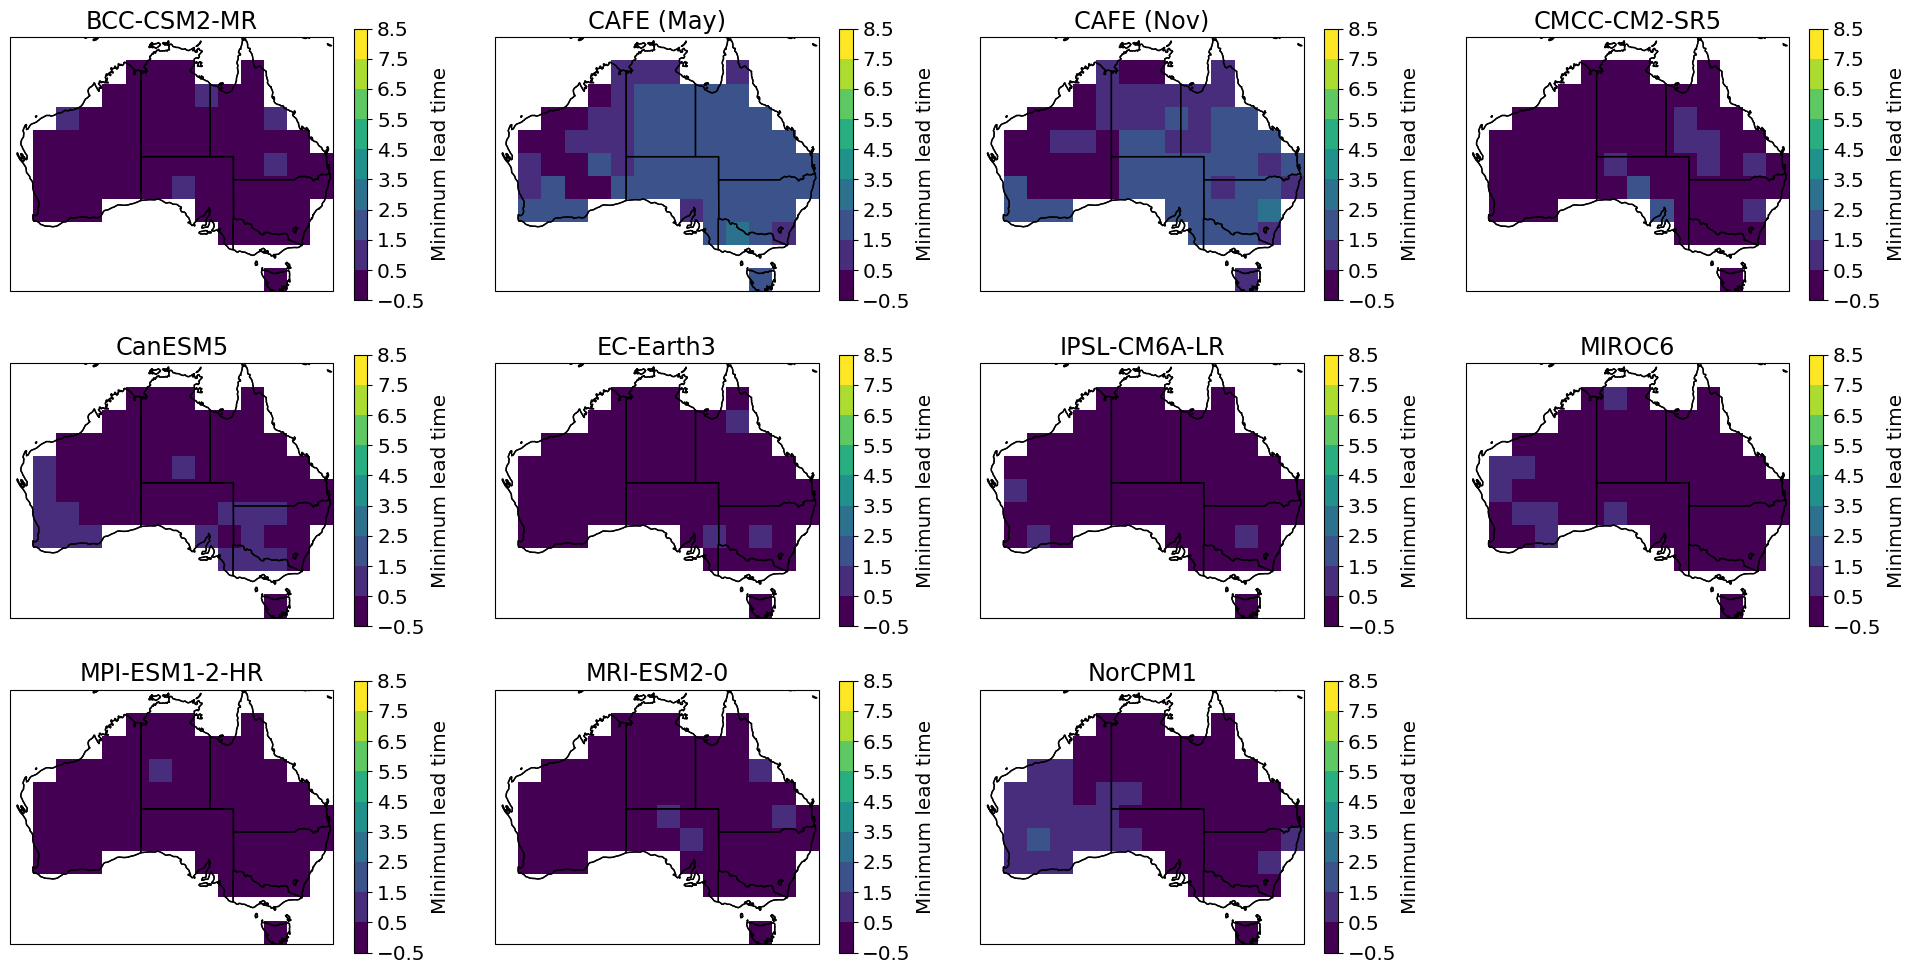

In [20]:
levels = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5] 

fig = plt.figure(figsize=[24, 12])

for plot_num, model in enumerate(models):
    ax = fig.add_subplot(3, 4, plot_num+1, projection=ccrs.PlateCarree())
    im = rx1day_dict[model].plot(ax=ax, transform=ccrs.PlateCarree(), levels=levels, cmap='viridis')
    ax.set_title(model)
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)

plt.show()